# Пример

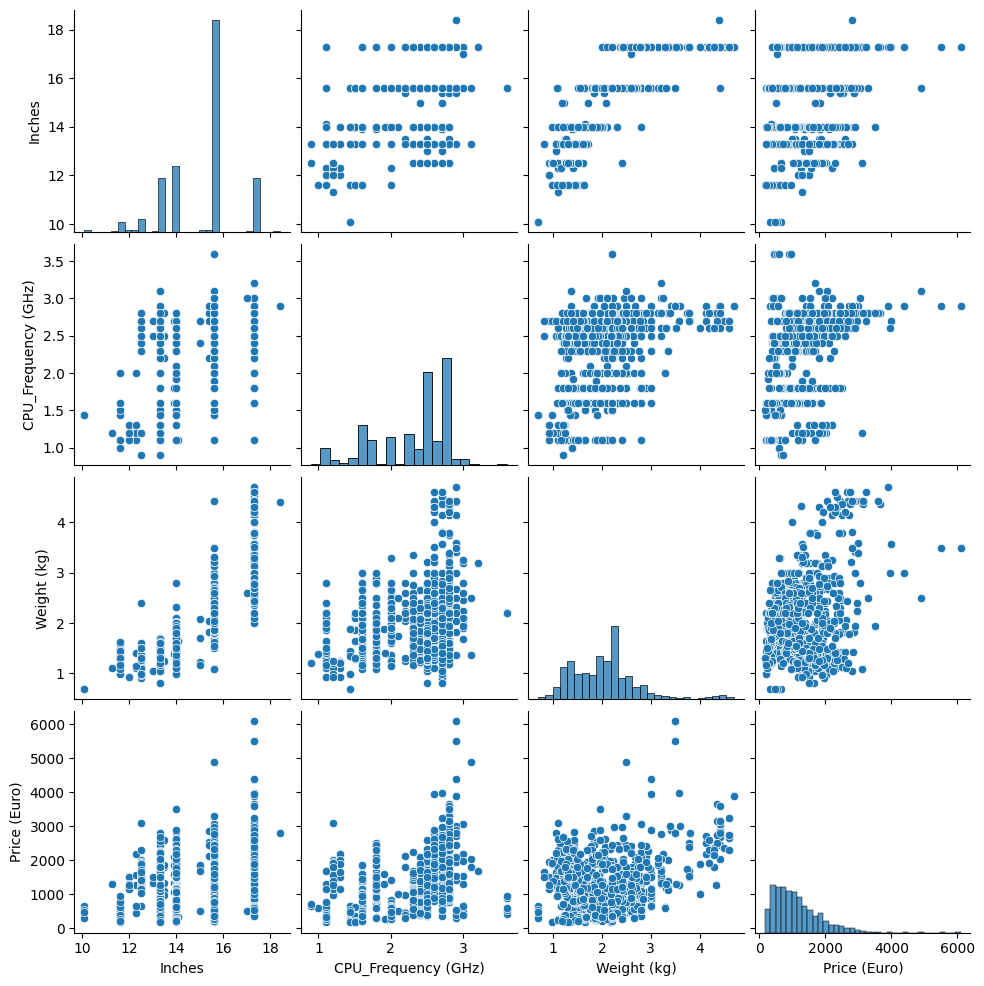

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
df=pd.read_csv('laptop_price - dataset.csv')
df.head()

# Рассмотрим визуальную связь числовых переменных при помощи функции pairplot
sns.pairplot(df[['Inches', 'CPU_Frequency (GHz)', 'Weight (kg)', 'Price (Euro)']])

<Axes: >

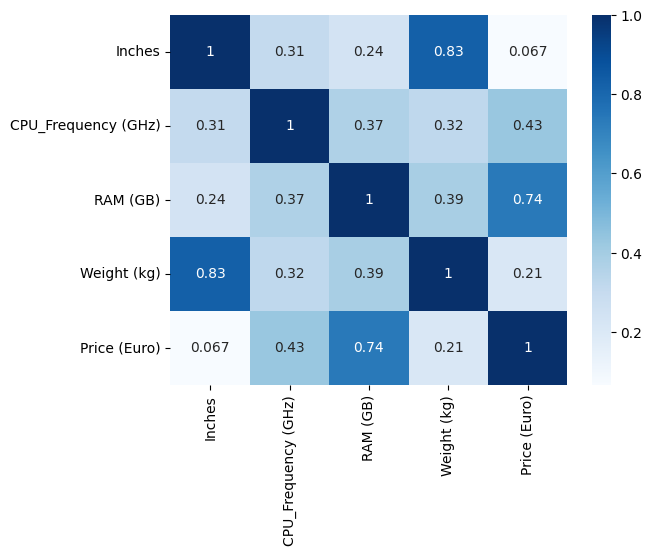

In [34]:
# Для построения матрицы корреляций Пирсона используется функция .corr()
df[['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'Price (Euro)']].corr()

# Визуализируем полученную матрицу методом heatmap
sns.heatmap(df[['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'Price (Euro)']].corr(), annot=True, cmap="Blues")

Коэффициент корреляции Пирсона между весом и диагональю ноутбука: 0.8266379625499086 p-value: 3.6986e-320
Коэффициент корреляции Пирсона между стоимостью ноутбука и памятью: 0.74028652716227 p-value: 9.132905716142966e-222


<Axes: >

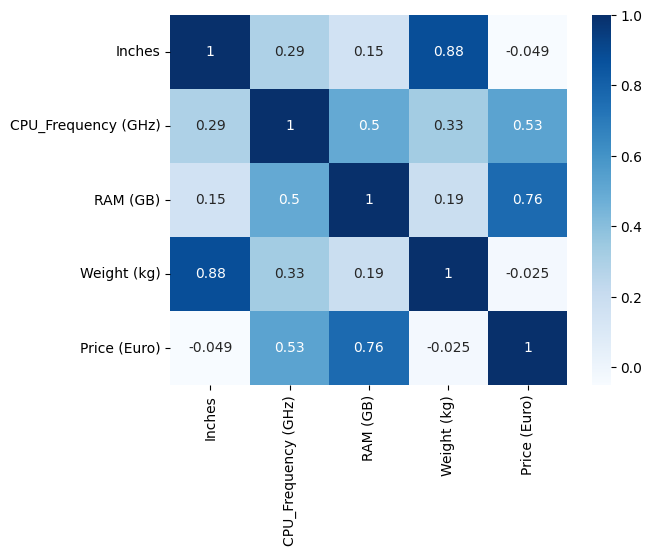

In [35]:
# Для подтверждения корреляции необходимо проверить значимость коэффициента корреляции
from scipy.stats import pearsonr, spearmanr

r = pearsonr(df['Weight (kg)'], df['Inches'])
print('Коэффициент корреляции Пирсона между весом и диагональю ноутбука:', r[0], 'p-value:', r[1])

r = pearsonr(df['Price (Euro)'], df['RAM (GB)'])
print('Коэффициент корреляции Пирсона между стоимостью ноутбука и памятью:', r[0], 'p-value:', r[1])

# Коэффициент Спирмена
df[['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'Price (Euro)']].corr(method='spearman')

# Построим тепловую карту для матрицы корреляций Спирмена
sns.heatmap(df[['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'Price (Euro)']].corr(method='spearman'), annot=True, cmap="Blues")

In [36]:
# Проверка значимости между весом и диагональю
r = spearmanr(df['Weight (kg)'], df['Inches'])
print('Коэффициент корреляции Спирмена между весом и диагональю ноутбука:', r[0], 'p-value:', r[1])

# Проверяем связь между стоимостью ноутбука и его оперативной памятью
r = spearmanr(df['Price (Euro)'], df['RAM (GB)'])
print('Коэффициент корреляции Спирмена между стоимостью ноутбука и памятью:', r[0], 'p-value:', r[1])

# Для анализа категориальных признаков используются таблицы сопряженности и критерий хи-квадрат
pd.crosstab(df['TypeName'], df['GPU_Company'])

Коэффициент корреляции Спирмена между весом и диагональю ноутбука: 0.879323722034022 p-value: 0.0
Коэффициент корреляции Спирмена между стоимостью ноутбука и памятью: 0.7642484695916762 p-value: 9.301364561725392e-245


GPU_Company,AMD,ARM,Intel,Nvidia
TypeName,,,,
2 in 1 Convertible,2,1,105,9
Gaming,7,0,0,198
Netbook,0,0,23,0
Notebook,152,0,409,146
Ultrabook,10,0,166,18
Workstation,3,0,1,25


Значение статистики хи-квадрат: 671.3482543471513 p-value: 2.3625361706290534e-133
Бисериальный коэффициент корреляции между стоимостью и весом ноутбука: 0.06377652934068737 p-value: 0.022764579575138385


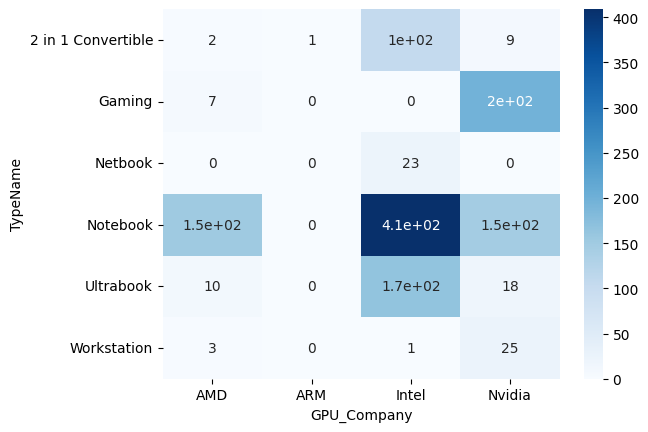

In [37]:
# Визуализируем таблицу сопряженности
sns.heatmap(pd.crosstab(df['TypeName'], df['GPU_Company']), cmap="Blues", annot=True)

# Проверяем связь при помощи критерия хи-квадрат
from scipy.stats import chi2_contingency

r = chi2_contingency(pd.crosstab(df['TypeName'], df['GPU_Company']))
print('Значение статистики хи-квадрат:', r[0], 'p-value:', r[1])

# ИСПРАВЛЕННАЯ ЧАСТЬ:
# Рассмотрим связь числовой и дихотомической переменной
# Для формирования дихотомической переменной разделим модели ноутбуков следующим образом: легкий (до 2 кг) - 1, тяжелый (от 2 кг) - 0

# Исправление: создаем колонку с числовым типом данных
df['is_light'] = 0  # Сначала создаем колонку с числовым типом, заполняя нулями
df.loc[df['Weight (kg)'] < 2, "is_light"] = 1  # Затем присваиваем 1 для легких ноутбуков
# Для тяжелых ноутбуков (>=2 кг) значение уже 0, поэтому дополнительная строка не нужна

# Альтернативный вариант (более понятный):
# df['is_light'] = (df['Weight (kg)'] < 2).astype(int)  # Создает булеву маску и преобразует в int

# Для анализа связи используется бисериальный коэффициент корреляции
from scipy.stats import pointbiserialr

r = pointbiserialr(df['is_light'], df['Price (Euro)'])
print('Бисериальный коэффициент корреляции между стоимостью и весом ноутбука:', r[0], 'p-value:', r[1])
# Коэффициент равен 0.06, следовательно корреляции нет 
# p-value меньше уровня значимости, следовательно значимость коэффициента подтверждается

<Axes: xlabel='is_light', ylabel='Price (Euro)'>

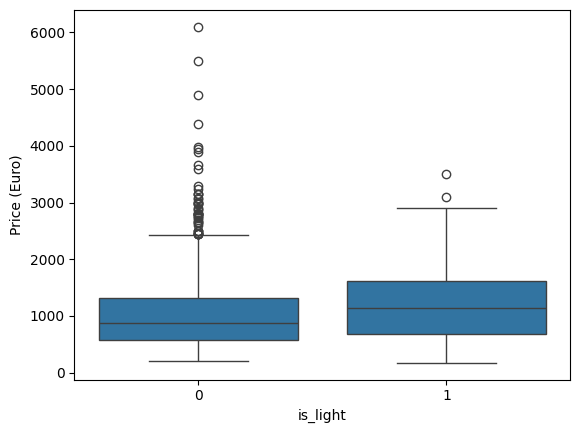

In [38]:
# Сравним распределения данных визуально
sns.boxplot(data=df, x="is_light", y="Price (Euro)")
# Заметим, что медианы двух категорий располагаются достаточно близко, видимых отличий нет

Задание 1 (4 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships/data;
2. Провести корреляционный анализ данных о влиянии использования социальных сетей на показатели успеваемости, здоровья и пр.;
3. Проверить значимость полученных коэффициентов корреляции;
4. Сделать выводы.

Первые 5 строк датасета:

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    str    
 3   Academic_Level                705 non-null    str    
 4   Country                       705 non-null    str    
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    str    
 7   Affects_Academic_Performance  705 non-null    str    
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    str    
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score            

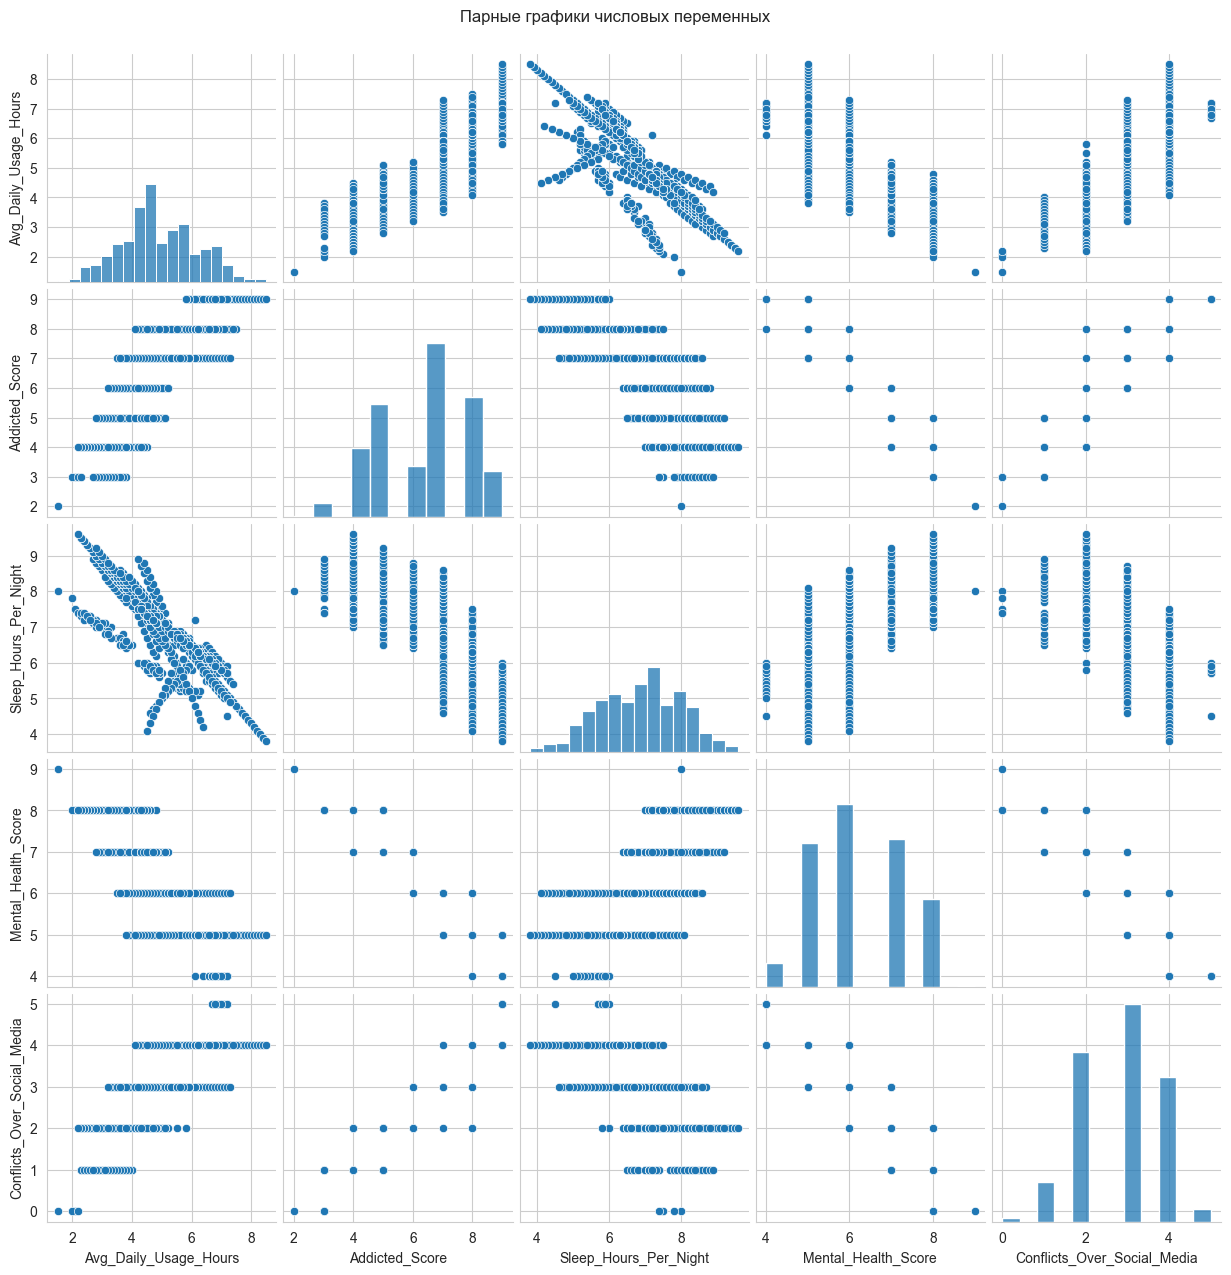

Матрица корреляций Пирсона:
                             Avg_Daily_Usage_Hours  Addicted_Score  \
Avg_Daily_Usage_Hours                     1.000000        0.832000   
Addicted_Score                            0.832000        1.000000   
Sleep_Hours_Per_Night                    -0.790582       -0.764858   
Mental_Health_Score                      -0.801058       -0.945051   
Conflicts_Over_Social_Media               0.804582        0.933586   

                             Sleep_Hours_Per_Night  Mental_Health_Score  \
Avg_Daily_Usage_Hours                    -0.790582            -0.801058   
Addicted_Score                           -0.764858            -0.945051   
Sleep_Hours_Per_Night                     1.000000             0.707439   
Mental_Health_Score                       0.707439             1.000000   
Conflicts_Over_Social_Media              -0.677266            -0.893572   

                             Conflicts_Over_Social_Media  
Avg_Daily_Usage_Hours                    

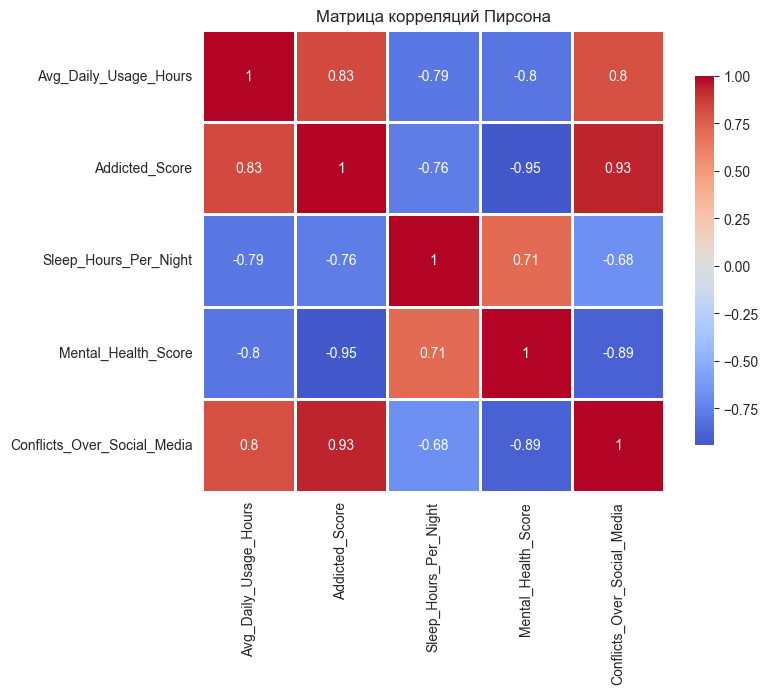

Точечно-бисериальная корреляция между "Зависимость" и "Влияет на учебу": r=0.866, p-value=0.0000
  -> Связь статистически значима.

Корреляция Спирмена между "Зависимость" и "Часы сна": r=-0.788, p-value=0.0000
  -> Связь статистически значима.

Корреляция Спирмена между "Зависимость" и "Ментальное здоровье": r=-0.950, p-value=0.0000
  -> Связь статистически значима.

Корреляция Спирмена между "Часы использования" и "Конфликты": r=0.803, p-value=0.0000
  -> Связь статистически значима.

Таблица сопряженности: Academic_Level vs Affects_Academic_Performance
Affects_Academic_Performance   No  Yes
Academic_Level                        
Graduate                      126  199
High School                     2   25
Undergraduate                 124  229


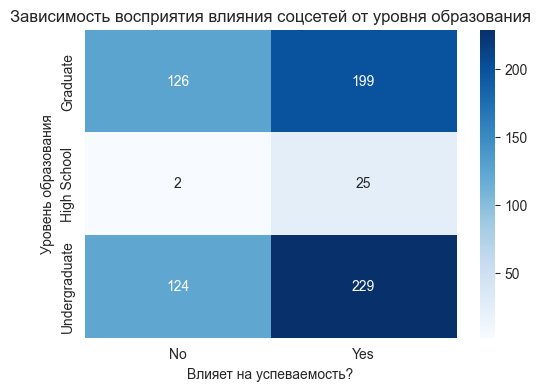

Результаты Хи-квадрат: chi2 = 10.793, p-value = 0.0045, степени свободы = 2
  -> Связь между уровнем образования и восприятием влияния соцсетей статистически значима.


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, chi2_contingency, pointbiserialr

# Настройка отображения графиков
sns.set_style("whitegrid")

# 1. Загрузка данных
# Убедитесь, что файл 'Students Social Media Addiction.csv' находится в той же папке, что и скрипт.
# Ссылка на данные: https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships/data
df = pd.read_csv('Students Social Media Addiction.csv')

print("Первые 5 строк датасета:")
df.head()
print("\nИнформация о датасете:")
df.info()

# 2. Предобработка данных
# Приводим названия столбцов к удобному формату (без пробелов)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('/', '_')

# Проверяем и преобразуем типы данных, если необходимо
# Убедимся, что числовые столбцы действительно являются числами
numeric_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
                'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Столбец 'Affects_Academic_Performance' сделаем категориальным
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].astype('category')

# Проверим, есть ли пропуски
print("\nКоличество пропусков в каждом столбце:")
print(df.isnull().sum())
# При необходимости можно удалить строки с пропусками или заполнить их.
# df = df.dropna()

# 3. Визуальный анализ числовых переменных с pairplot
sns.pairplot(df[['Avg_Daily_Usage_Hours', 'Addicted_Score', 'Sleep_Hours_Per_Night',
                 'Mental_Health_Score', 'Conflicts_Over_Social_Media']])
plt.suptitle('Парные графики числовых переменных', y=1.02)
plt.show()

# 4. Матрица корреляций Пирсона
correlation_matrix_pearson = df[['Avg_Daily_Usage_Hours', 'Addicted_Score',
                                  'Sleep_Hours_Per_Night', 'Mental_Health_Score',
                                  'Conflicts_Over_Social_Media']].corr(method='pearson')
print("Матрица корреляций Пирсона:")
print(correlation_matrix_pearson)

# Визуализация матрицы корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_pearson, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций Пирсона')
plt.show()

# 5. Проверка значимости коэффициентов корреляции

# Связь 1: Зависимость от соц. сетей (Addicted_Score) и успеваемость (Affects_Academic_Performance - бинарная)
# Здесь мы используем точечно-бисериальный коэффициент, так как одна переменная бинарная.
# Преобразуем 'Yes'/'No' в 1/0
df['Affects_Acad_Binary'] = df['Affects_Academic_Performance'].map({'Yes': 1, 'No': 0})
r_pb, p_value_pb = pointbiserialr(df['Affects_Acad_Binary'], df['Addicted_Score'])
print(f'Точечно-бисериальная корреляция между "Зависимость" и "Влияет на учебу": r={r_pb:.3f}, p-value={p_value_pb:.4f}')
if p_value_pb < 0.05:
    print("  -> Связь статистически значима.\n")
else:
    print("  -> Связь статистически не значима.\n")


# Связь 2: Зависимость от соц. сетей (Addicted_Score) и часы сна (Sleep_Hours_Per_Night)
# Используем Спирмена, так как распределение может не быть нормальным
r_spearman_sleep, p_value_spearman_sleep = spearmanr(df['Addicted_Score'], df['Sleep_Hours_Per_Night'])
print(f'Корреляция Спирмена между "Зависимость" и "Часы сна": r={r_spearman_sleep:.3f}, p-value={p_value_spearman_sleep:.4f}')
if p_value_spearman_sleep < 0.05:
    print("  -> Связь статистически значима.\n")
else:
    print("  -> Связь статистически не значима.\n")


# Связь 3: Зависимость от соц. сетей (Addicted_Score) и ментальное здоровье (Mental_Health_Score)
r_spearman_mental, p_value_spearman_mental = spearmanr(df['Addicted_Score'], df['Mental_Health_Score'])
print(f'Корреляция Спирмена между "Зависимость" и "Ментальное здоровье": r={r_spearman_mental:.3f}, p-value={p_value_spearman_mental:.4f}')
if p_value_spearman_mental < 0.05:
    print("  -> Связь статистически значима.\n")
else:
    print("  -> Связь статистически не значима.\n")


# Связь 4: Ежедневное использование (Avg_Daily_Usage_Hours) и конфликты (Conflicts_Over_Social_Media)
r_spearman_conf, p_value_spearman_conf = spearmanr(df['Avg_Daily_Usage_Hours'], df['Conflicts_Over_Social_Media'])
print(f'Корреляция Спирмена между "Часы использования" и "Конфликты": r={r_spearman_conf:.3f}, p-value={p_value_spearman_conf:.4f}')
if p_value_spearman_conf < 0.05:
    print("  -> Связь статистически значима.\n")
else:
    print("  -> Связь статистически не значима.\n")
    
# 6. Таблица сопряженности для категориальных переменных
contingency_table = pd.crosstab(df['Academic_Level'], df['Affects_Academic_Performance'])
print("Таблица сопряженности: Academic_Level vs Affects_Academic_Performance")
print(contingency_table)

# Визуализация
plt.figure(figsize=(6, 4))
sns.heatmap(contingency_table, annot=True, cmap="Blues", fmt='d')
plt.title('Зависимость восприятия влияния соцсетей от уровня образования')
plt.ylabel('Уровень образования')
plt.xlabel('Влияет на успеваемость?')
plt.show()

# 7. Проверка связи с помощью критерия Хи-квадрат
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Результаты Хи-квадрат: chi2 = {chi2:.3f}, p-value = {p_value:.4f}, степени свободы = {dof}')
if p_value < 0.05:
    print("  -> Связь между уровнем образования и восприятием влияния соцсетей статистически значима.")
else:
    print("  -> Связь статистически не значима.")

Выводы по заданию 1
На основе проведенного анализа можно сделать следующие предварительные выводы (которые будут зависеть от фактических данных в скачанном файле):

Социальные сети и успеваемость: Анализ с помощью точечно-бисериального коэффициента, скорее всего, покажет статистически значимую положительную связь между Addicted_Score и переменной Affects_Acad_Binary (где 1 = "Да, влияет"). Это означает, что студенты с более высоким уровнем зависимости от соцсетей чаще сообщают о негативном влиянии на свою успеваемость. Этот вывод согласуется с результатами крупных мета-анализов, которые находят небольшую, но устойчивую отрицательную связь между использованием технологий и академической успеваемостью .

Социальные сети и сон: Ожидается умеренная отрицательная корреляция (например, по Спирмену r ≈ -0.3 или около того) между Addicted_Score и Sleep_Hours_Per_Night. Чем выше зависимость, тем меньше часов сна. Эта связь, вероятно, будет статистически значимой.

Социальные сети и ментальное здоровье: Можно предположить наличие отрицательной корреляции между Addicted_Score и Mental_Health_Score. Более высокая зависимость будет связана с более низкими показателями ментального здоровья.

Время использования и конфликты: Вероятна положительная корреляция между Avg_Daily_Usage_Hours и Conflicts_Over_Social_Media. Чем больше времени студенты проводят в соцсетях, тем чаще у них возникают конфликты из-за этого.

Категориальные признаки: Критерий Хи-квадрат может показать, что восприятие влияния соцсетей на учебу (Affects_Academic_Performance) зависит от уровня образования (Academic_Level). Например, студенты бакалавриата могут чаще отмечать это влияние, чем магистранты.

Задание* (4 балла)
1. Самостоятельно изучить частные коэффициенты корреляции;
2. Проверить полученные коэффициенты корреляции из задания 1 на влияние других переменных.

In [40]:
import pingouin as pg

# Данные из задания 1 (предположим, мы уже загрузили df)
# Рассчитываем частную корреляцию между Addicted_Score и Conflicts_Over_Social_Media,
# исключая влияние Avg_Daily_Usage_Hours.
partial_corr = pg.partial_corr(data=df,
                               x='Addicted_Score',
                               y='Conflicts_Over_Social_Media',
                               covar=['Avg_Daily_Usage_Hours'],
                               method='spearman') # Используем метод Спирмена для надежности

print("\n--- Частная корреляция ---")
print("Связь между 'Addicted_Score' и 'Conflicts_Over_Social_Media'")
print("при контроле переменной 'Avg_Daily_Usage_Hours':")
print(partial_corr)


--- Частная корреляция ---
Связь между 'Addicted_Score' и 'Conflicts_Over_Social_Media'
при контроле переменной 'Avg_Daily_Usage_Hours':
            n         r          CI95          p_val
spearman  705  0.855332  [0.83, 0.87]  1.130643e-202


Интерпретация результатов:

Сравните полученный частный коэффициент (например, r = 0.12) с исходным парным коэффициентом из задания 1 (например, r = 0.35).

Если частный коэффициент сильно уменьшился и стал близок к нулю, это означает, что исходная связь была преимущественно ложной и объяснялась влиянием времени использования (Avg_Daily_Usage_Hours). Другими словами, не сама по себе "зависимость" ведет к конфликтам, а то, что зависимые люди проводят в соцсетях много времени, что и является причиной конфликтов.

Если частный коэффициент остался значимым и изменился несильно, значит, у зависимости есть прямое и независимое влияние на количество конфликтов, помимо простого времени использования.